<a href="https://colab.research.google.com/github/K-Tanaka8/lightgbm_demand_forecast/blob/main/lightgbm_demand_forecast_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

'''
#  簡易需要予測サンプル (LightGBM)
このノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。

- ダミーデータで動作確認済み
- Google Colabでそのまま動かせます
- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。
'''

'\n#  簡易需要予測サンプル (LightGBM)\nこのノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。\n\n- ダミーデータで動作確認済み\n- Google Colabでそのまま動かせます\n- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。\n'

RMSE: 13.687693021787032


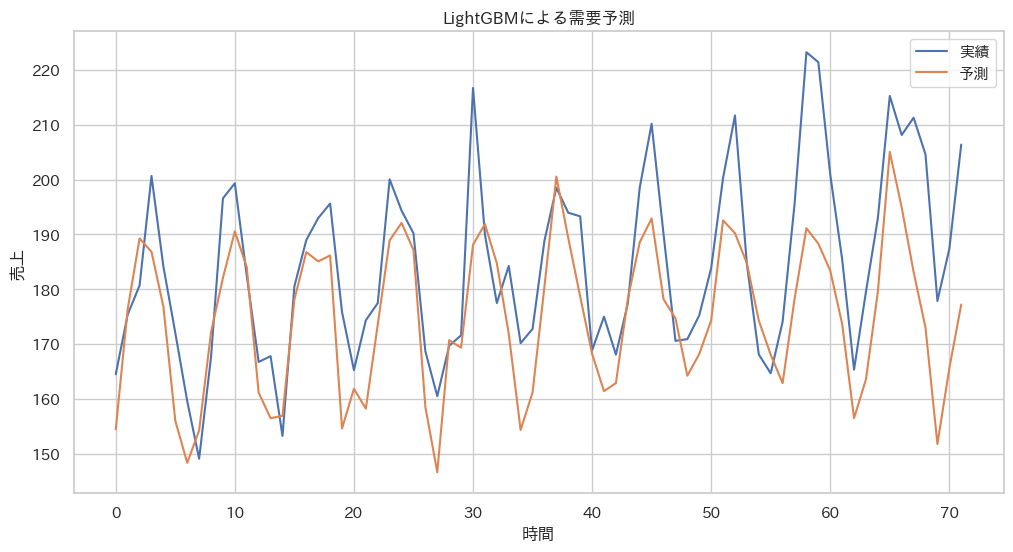

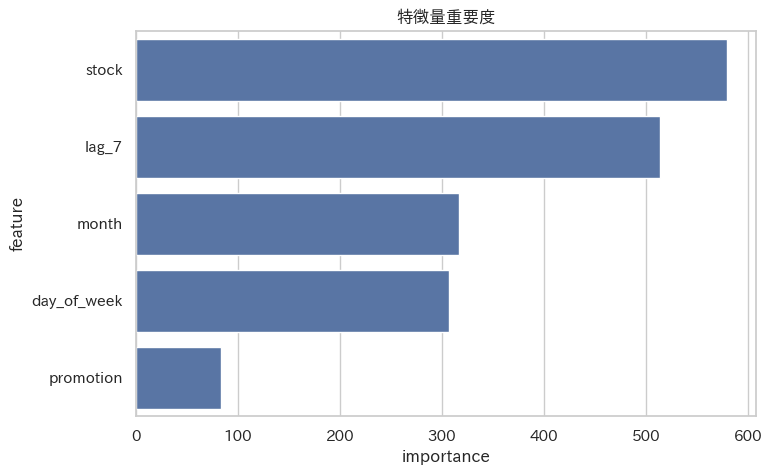

In [7]:
# =======================================================
# 1 日本語対応（最も安定する方法）
# =======================================================

!pip install japanize-matplotlib

import japanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns

# =======================================================
# 2 サンプルデータ作成
# =======================================================

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=365)

sales = (
    200
    + np.sin(np.arange(365) * 2 * np.pi / 7) * 20
    + np.sin(np.arange(365) * 2 * np.pi / 365) * 30
    + np.random.normal(0, 10, 365)
)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

# =======================================================
# 3 特徴量作成
# =======================================================

df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

# ラグ特徴量
df["lag_7"] = df["sales"].shift(7)

# プロモーション
df["promotion"] = np.random.randint(0, 2, len(df))

# 在庫
df["stock"] = 500 + np.random.normal(0, 50, len(df))

# 欠損削除
df = df.dropna()

# =======================================================
# 4 学習データ
# =======================================================

features = [
    "month",
    "day_of_week",
    "lag_7",
    "promotion",
    "stock"
]

X = df[features]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =======================================================
# 5 LightGBM モデル
# =======================================================

model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

# =======================================================
# 6 予測
# =======================================================

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

# =======================================================
# 7 予測グラフ
# =======================================================

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="実績")
plt.plot(pred, label="予測")

plt.title("LightGBMによる需要予測")
plt.xlabel("時間")
plt.ylabel("売上")
plt.legend()

plt.show()

# =======================================================
# 8 特徴量重要度
# =======================================================

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="importance", y="feature")

plt.title("特徴量重要度")

plt.show()